# Final Results

Reproduces the headline numbers and the figures shown in the presentation (`presentation/slides.pdf`).
Reads the already-exported `results/` and `data/processed/disruption_score/` tables — no full trip data
needed. Outputs are written to `results/final/`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
import shapefile
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

REPO = Path.cwd().resolve()
while not (REPO/'results').exists() and REPO != REPO.parent: REPO = REPO.parent
DS   = REPO/'data'/'processed'/'disruption_score'
BUR  = REPO/'results'/'burden_analysis'/'tables'
MOD  = REPO/'results'/'modeling'/'tables'
EDAT = REPO/'results'/'eda'/'tables'
FIG  = REPO/'results'/'final'/'figures'; FIG.mkdir(parents=True, exist_ok=True)
pd.set_option('display.width', 150); pd.set_option('display.max_columns', 40)

dv_y = pd.read_csv(DS/'yellow_ds_z_vs_volume_change.csv')   # Yellow DS_z per zone × direction
dv_h = pd.read_csv(DS/'hvfhv_ds_z_vs_volume_change.csv')    # Uber/Lyft DS_z per zone × direction
print('Loaded results tables. Figures -> results/final/figures/')

Loaded results tables. Figures -> results/final/figures/


## Goal 1 — Burden ranking, airport contrast, stability

Burden is a much larger share of short, low-cost trips; the ranking is stable across floor choices.

In [2]:
for svc, name in [('yellow','Yellow'), ('hvfhv','Uber/Lyft')]:
    top = pd.read_csv(BUR/f'{svc}_top_dsz_zone_directions.csv').head(5)
    ap  = pd.read_csv(BUR/f'{svc}_airport_vs_nonairport_burden.csv')
    fs  = pd.read_csv(BUR/f'{svc}_dsz_floor_rank_stability.csv')
    ov  = pd.read_csv(BUR/f'{svc}_dsz_floor_top_overlap.csv')
    print(f'===== {name} =====')
    print('Top-5 burden zone-sides (DS_z):')
    print(top[['zone_name','direction','DS_z','N_z']].to_string(index=False))
    print('Airport vs non-airport median burden:', dict(zip(ap.group, ap.med_burden_charged.round(4))))
    print(f'Floor rank stability: Spearman {fs.spearman_rank_corr_vs_primary.min():.4f}-{fs.spearman_rank_corr_vs_primary.max():.4f} '
          f'vs $1 primary; top-10/20 overlap min {ov.overlap_share.min():.0%}\n')

===== Yellow =====
Top-5 burden zone-sides (DS_z):
   zone_name direction   DS_z    N_z
    Kips Bay   dropoff 0.0476 174406
    Flatiron    pickup 0.0475 235158
    Flatiron   dropoff 0.0473 219240
    Union Sq   dropoff 0.0471 372281
West Village   dropoff 0.0467 263614
Airport vs non-airport median burden: {'non-airport': 0.0419, 'airport': 0.0099}
Floor rank stability: Spearman 0.9962-1.0000 vs $1 primary; top-10/20 overlap min 100%

===== Uber/Lyft =====
Top-5 burden zone-sides (DS_z):
                     zone_name direction     DS_z    N_z
                 Alphabet City   dropoff 0.063806 239356
Stuy Town/Peter Cooper Village   dropoff 0.063063 160441
                  East Village   dropoff 0.062506 983593
                  West Village   dropoff 0.061943 742528
       Greenwich Village South   dropoff 0.061734 526218
Airport vs non-airport median burden: {'non-airport': 0.0467, 'airport': 0.0169}
Floor rank stability: Spearman 1.0000-1.0000 vs $1 primary; top-10/20 overlap min

## Burden maps — DS_z by TLC zone (presentation slide 7)

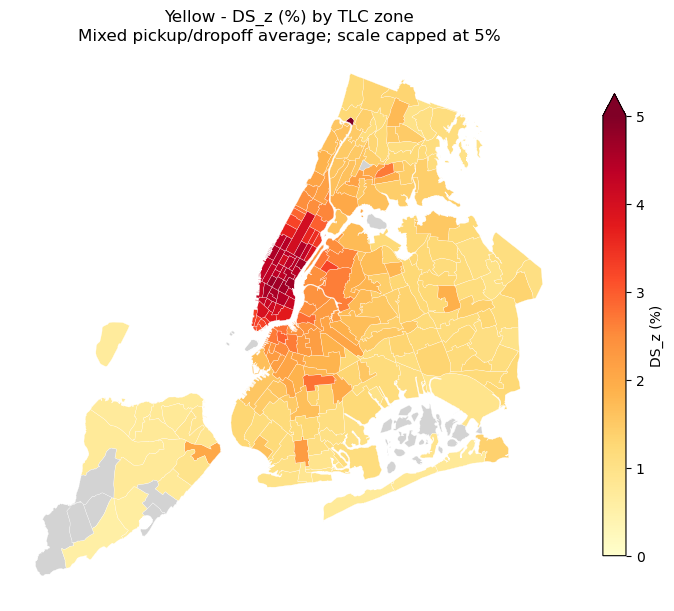

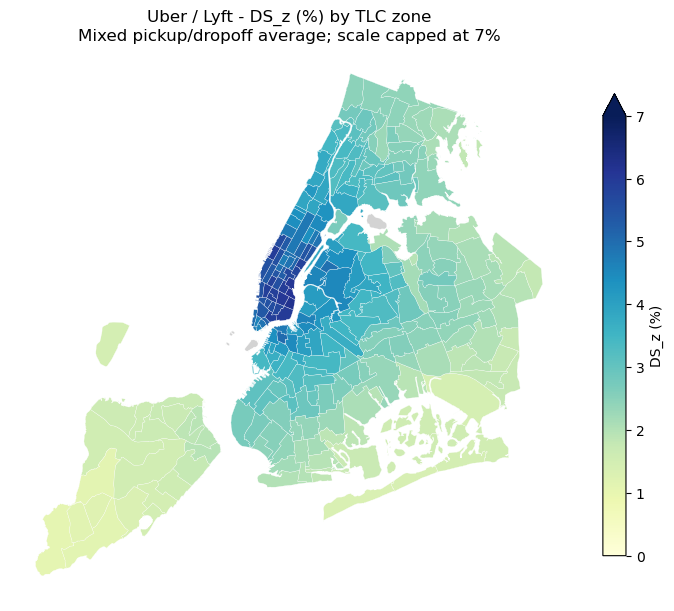

In [3]:
sf = shapefile.Reader(str(REPO/'data'/'geo'/'taxi_zones'/'taxi_zones.shp'))

def choropleth(dv, service, cmap, cap, out_name):
    zmean = dv[~dv.low_n_flag].groupby('zone').DS_z.mean()
    patches, vals = [], []
    for rec, shp in zip(sf.records(), sf.shapes()):
        v = zmean.get(rec['LocationID'], np.nan)
        parts = list(shp.parts) + [len(shp.points)]
        for i in range(len(parts)-1):
            patches.append(Polygon(shp.points[parts[i]:parts[i+1]], closed=True)); vals.append(v)
    vals = np.array(vals, float) * 100
    cm = cmap.copy(); cm.set_bad('lightgrey')
    fig, ax = plt.subplots(figsize=(9, 10))
    pc = PatchCollection(patches, cmap=cm, edgecolor='white', linewidth=0.2)
    pc.set_array(np.ma.masked_invalid(vals)); pc.set_clim(0, cap)
    ax.add_collection(pc); ax.autoscale_view(); ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'{service} - DS_z (%) by TLC zone\nMixed pickup/dropoff average; scale capped at {cap:g}%')
    cb = fig.colorbar(pc, ax=ax, shrink=0.6, extend='max'); cb.set_label('DS_z (%)')
    fig.savefig(FIG/out_name, dpi=150, bbox_inches='tight'); plt.show()

choropleth(dv_y, 'Yellow',     plt.cm.YlOrRd, 5, 'yellow_dsz_choropleth.png')
choropleth(dv_h, 'Uber / Lyft', plt.cm.YlGnBu, 7, 'hvfhv_dsz_choropleth.png')

## Goal 2 — Volume models: estimates (beta / %) and placebo tests

The main estimates are negative. The no-fee placebo and sensitivity checks limit a direct fee-caused interpretation.

In [4]:
print('--- Model 1: DS_z <-> volume correlation ---')
for svc in ['yellow','hvfhv']:
    print(f'{svc}:'); print(pd.read_csv(MOD/f'{svc}_model1_correlations.csv').round(3).to_string(index=False))

print('\n--- Model 2: exposure DiD estimates (%) ---')
for svc in ['yellow','hvfhv']:
    print(f'{svc}:'); print(pd.read_csv(MOD/f'{svc}_model2_estimates.csv').round(2).to_string(index=False))
    dpath = MOD/f'{svc}_model2_diagnostics.csv'
    if dpath.exists():
        print(f'{svc} diagnostics (incl. placebo):'); print(pd.read_csv(dpath).round(3).to_string(index=False))

print('\n--- Model 3: cross-vehicle DiD estimates + placebo/provider diagnostics ---')
print(pd.read_csv(MOD/'cross_vehicle_model3_estimates.csv').round(2).to_string(index=False))
print(pd.read_csv(MOD/'cross_vehicle_model3_diagnostics.csv').round(2).to_string(index=False))

--- Model 1: DS_z <-> volume correlation ---
yellow:
                          metric   method   n  correlation  ci_low  ci_high
       DS_z vs pct_volume_change  pearson 328       -0.170  -0.273   -0.063
       DS_z vs pct_volume_change spearman 328       -0.163  -0.267   -0.056
DS_z_median vs pct_volume_change  pearson 328       -0.177  -0.280   -0.070
DS_z_median vs pct_volume_change spearman 328       -0.186  -0.288   -0.079
hvfhv:
                          metric   method   n  correlation  ci_low  ci_high
       DS_z vs pct_volume_change  pearson 519       -0.610  -0.661   -0.553
       DS_z vs pct_volume_change spearman 519       -0.643  -0.691   -0.589
DS_z_median vs pct_volume_change  pearson 519       -0.599  -0.652   -0.541
DS_z_median vs pct_volume_change spearman 519       -0.637  -0.686   -0.583

--- Model 2: exposure DiD estimates (%) ---
yellow:
           window                           spec  estimate_pct  ci_low  ci_high
        2024→2025  higher-exposure, equal-weigh

## DS_z vs volume — TLC bubble charts (presentation slide 9)

Each bubble is one zone-side, with area proportional to the charged-trip count used to estimate `DS_z`.

Yellow Taxi: 328 zone-sides; Pearson r = -0.170; saved yellow_model1_dsz_vs_volume.png


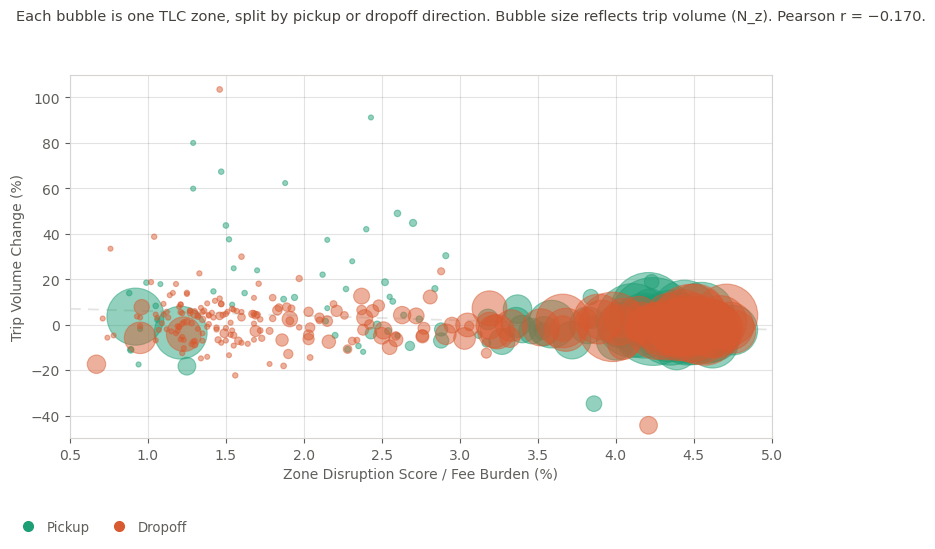

Uber/Lyft: 519 zone-sides; Pearson r = -0.610; saved hvfhv_model1_dsz_vs_volume.png


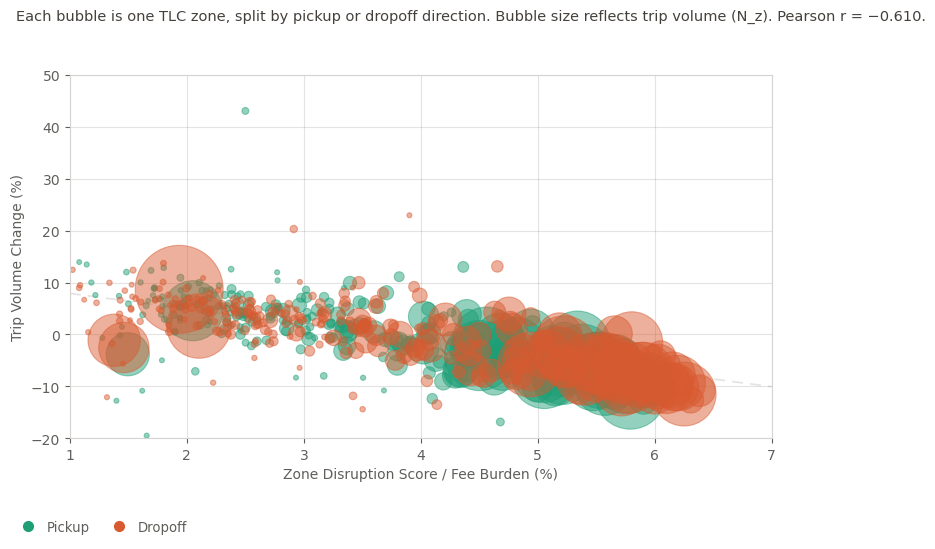

In [5]:
import sys
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from scripts.model1_bubble_chart import plot_model1_bubble_chart

for data, service, name, xlim, ylim, min_burden_n in [
    (dv_y, "Yellow Taxi", "yellow_model1_dsz_vs_volume.png", (0.5, 5.0), (-50, 110), 100),
    (dv_h, "Uber/Lyft", "hvfhv_model1_dsz_vs_volume.png", (1.0, 7.0), (-20, 50), None),
]:
    fig, ax, used, r = plot_model1_bubble_chart(
        data,
        service,
        FIG / name,
        xlim=xlim,
        ylim=ylim,
        min_burden_n=min_burden_n,
    )
    print(f"{service}: {len(used)} zone-sides; Pearson r = {r:.3f}; saved {name}")
    plt.show()


## EDA figures shown in the presentation (slide 5)

Reproduced from the exported EDA summary tables.

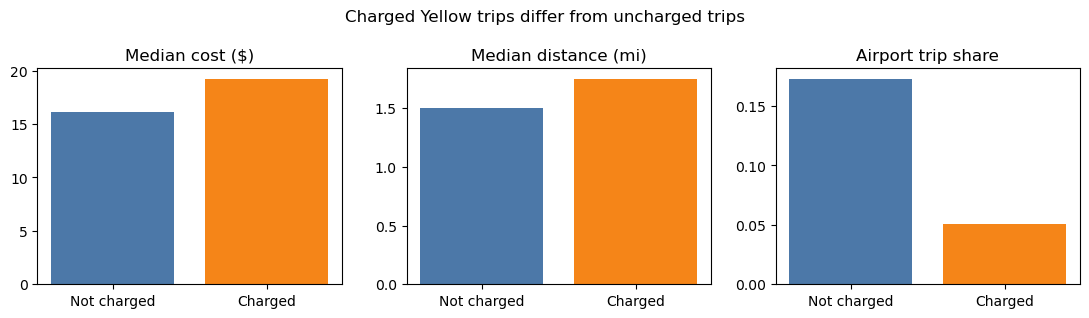

In [6]:
# (a) Charged vs uncharged Yellow trips
cc = pd.read_csv(EDAT/'yellow_full_charged_comparison_2025.csv').set_index('charged_cbd_flag')
labels = {True: 'Charged', False: 'Not charged'}; order = [False, True]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, col, ttl in zip(axes, ['median_cost','median_distance','airport_share'],
                        ['Median cost ($)','Median distance (mi)','Airport trip share']):
    ax.bar([labels[k] for k in order], [cc.loc[k, col] for k in order], color=['#4C78A8','#F58518'])
    ax.set_title(ttl)
fig.suptitle('Charged Yellow trips differ from uncharged trips'); plt.tight_layout()
fig.savefig(FIG/'yellow_full_charged_vs_uncharged.png', dpi=150, bbox_inches='tight'); plt.show()

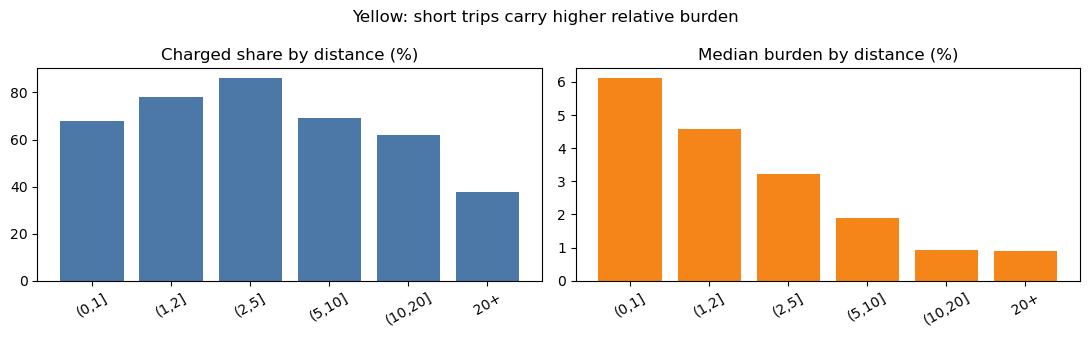

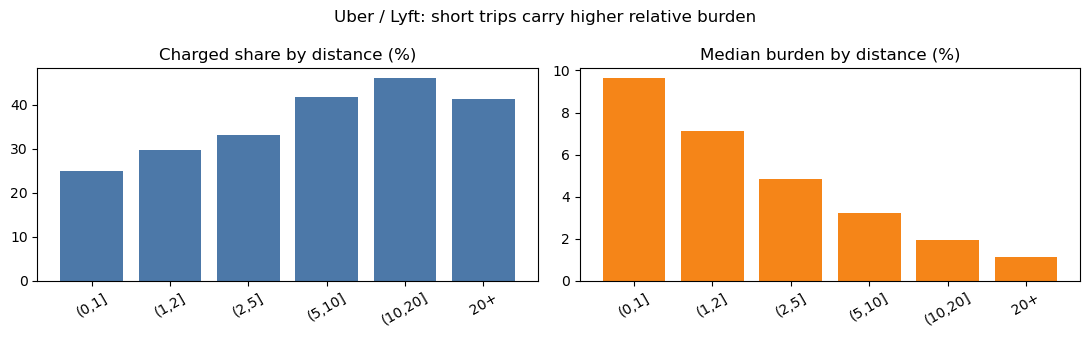

In [7]:
# (b) Burden and charged-share by distance bucket — Yellow and Uber/Lyft
def distance_fig(csv, service, out_name):
    d = pd.read_csv(EDAT/csv).sort_values('bucket_order')
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    ax[0].bar(d.distance_bucket, d.charged_cbd_share*100, color='#4C78A8')
    ax[0].set_title('Charged share by distance (%)'); ax[0].tick_params(axis='x', rotation=30)
    ax[1].bar(d.distance_bucket, d.median_base_cost_burden_floor1*100, color='#F58518')
    ax[1].set_title('Median burden by distance (%)'); ax[1].tick_params(axis='x', rotation=30)
    fig.suptitle(f'{service}: short trips carry higher relative burden'); plt.tight_layout()
    fig.savefig(FIG/out_name, dpi=150, bbox_inches='tight'); plt.show()

distance_fig('yellow_full_distance_exposure_2025.csv', 'Yellow', 'yellow_full_burden_by_distance.png')
distance_fig('hvfhv_full_distance_exposure_2025.csv', 'Uber / Lyft', 'hvfhv_full_distance_exposure_2025.png')

## KPI tables behind the presentation

The exact tables that back the headline numbers, collected into `results/final/tables/`.

In [8]:
# Gather the presentation's KPI tables into one place (verbatim copies of the source tables).
import shutil
FTAB = REPO/'results'/'final'/'tables'; FTAB.mkdir(parents=True, exist_ok=True)
kpi_sources = [
    BUR/'yellow_top_dsz_zone_directions.csv',   BUR/'hvfhv_top_dsz_zone_directions.csv',
    BUR/'yellow_airport_vs_nonairport_burden.csv', BUR/'hvfhv_airport_vs_nonairport_burden.csv',
    BUR/'yellow_dsz_floor_rank_stability.csv',  BUR/'hvfhv_dsz_floor_rank_stability.csv',
    BUR/'yellow_dsz_floor_top_overlap.csv',     BUR/'hvfhv_dsz_floor_top_overlap.csv',
    MOD/'yellow_model1_correlations.csv',       MOD/'hvfhv_model1_correlations.csv',
    MOD/'yellow_model2_estimates.csv',          MOD/'hvfhv_model2_estimates.csv',
    MOD/'hvfhv_model2_diagnostics.csv',
    MOD/'cross_vehicle_model3_estimates.csv',   MOD/'cross_vehicle_model3_diagnostics.csv',
]
for src in kpi_sources:
    shutil.copyfile(src, FTAB/src.name)
print(f'Wrote {len(kpi_sources)} KPI tables to results/final/tables/:')
for p in sorted(FTAB.glob('*.csv')): print('  ', p.name)

Wrote 15 KPI tables to results/final/tables/:
   cross_vehicle_model3_diagnostics.csv
   cross_vehicle_model3_estimates.csv
   hvfhv_airport_vs_nonairport_burden.csv
   hvfhv_dsz_floor_rank_stability.csv
   hvfhv_dsz_floor_top_overlap.csv
   hvfhv_model1_correlations.csv
   hvfhv_model2_diagnostics.csv
   hvfhv_model2_estimates.csv
   hvfhv_top_dsz_zone_directions.csv
   yellow_airport_vs_nonairport_burden.csv
   yellow_dsz_floor_rank_stability.csv
   yellow_dsz_floor_top_overlap.csv
   yellow_model1_correlations.csv
   yellow_model2_estimates.csv
   yellow_top_dsz_zone_directions.csv
